
# LSTM Autoencoder for Network Anomaly Detection
Full example with synthetic Modbus-like traffic data


In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
# ============================================================
# 1. GENERATE FAKE DATA
# ============================================================

NUM_PACKETS = 20000

def generate_clean_traffic(n):
    """Simulate normal Modbus traffic"""
    data = {
        "rtt": np.random.normal(5.0, 1.5, n).clip(1, 20),
        "packet_length": np.random.normal(100, 15, n).clip(60, 200),
        "inter_arrival": np.random.exponential(0.5, n).clip(0.01, 5),
        "payload_size": np.random.normal(50, 10, n).clip(10, 150),
        "function_code": np.random.choice([1, 2, 3, 4, 5, 6], n),
    }
    return np.column_stack(list(data.values()))

def generate_mitm_traffic(n):
    """Simulate MITM traffic with oscillating RTT and mixed clean packets"""
    data = generate_clean_traffic(n)  # start with clean base

    # Create MITM regions (60% of packets are attack)
    mitm_mask = np.zeros(n, dtype=bool)
    # Attack in chunks (simulating MITM active periods)
    chunk_starts = [2000, 5000, 8000, 12000, 16000]
    for start in chunk_starts:
        end = min(start + 2500, n)
        mitm_mask[start:end] = True

    # MITM signature: oscillating RTT pattern + higher baseline
    t = np.arange(n)
    oscillation = 3.0 * np.sin(2 * np.pi * t / 200)  # periodic wave
    data[mitm_mask, 0] += oscillation[mitm_mask] + 4.0  # RTT boost + oscillation

    # MITM also slightly increases packet length and inter-arrival
    data[mitm_mask, 1] += np.random.normal(20, 5, mitm_mask.sum())
    data[mitm_mask, 2] += np.random.normal(0.3, 0.1, mitm_mask.sum())

    return data, mitm_mask

print("Generating synthetic data...")
clean_data = generate_clean_traffic(NUM_PACKETS)
mitm_data, mitm_mask = generate_mitm_traffic(NUM_PACKETS)

print(f"Clean data shape: {clean_data.shape}")
print(f"MITM data shape:  {mitm_data.shape}")
print(f"MITM packets:     {mitm_mask.sum()} / {NUM_PACKETS} ({mitm_mask.mean()*100:.0f}%)")

Generating synthetic data...
Clean data shape: (20000, 5)
MITM data shape:  (20000, 5)
MITM packets:     12500 / 20000 (62%)


In [4]:
# ============================================================
# 2. NORMALIZE
# ============================================================

scaler = MinMaxScaler()
clean_scaled = scaler.fit_transform(clean_data)
mitm_scaled = scaler.transform(mitm_data)

In [5]:
# ============================================================
# 3. CREATE SLIDING WINDOWS
# ============================================================

WINDOW_SIZE = 50

def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i : i + window_size])
    return np.array(windows)

X_clean = create_windows(clean_scaled, WINDOW_SIZE)
X_mitm = create_windows(mitm_scaled, WINDOW_SIZE)

# Window-level labels (window is anomalous if >50% of packets are MITM)
window_labels = np.array([
    mitm_mask[i : i + WINDOW_SIZE].mean() > 0.5
    for i in range(len(mitm_mask) - WINDOW_SIZE)
]).astype(int)

# Train/val split
split = int(0.9 * len(X_clean))
X_train = X_clean[:split]
X_val = X_clean[split:]

print(f"\nTrain windows: {X_train.shape}")
print(f"Val windows:   {X_val.shape}")
print(f"MITM windows:  {X_mitm.shape}")


Train windows: (17955, 50, 5)
Val windows:   (1995, 50, 5)
MITM windows:  (19950, 50, 5)


In [6]:
# ============================================================
# 4. BUILD LSTM AUTOENCODER
# ============================================================

num_features = 5

inputs = Input(shape=(WINDOW_SIZE, num_features))

# Encoder
encoded = LSTM(64, activation="relu", return_sequences=True)(inputs)
encoded = LSTM(32, activation="relu")(encoded)

# Bridge
bridge = RepeatVector(WINDOW_SIZE)(encoded)

# Decoder
decoded = LSTM(32, activation="relu", return_sequences=True)(bridge)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(num_features))(decoded)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,813 (249.27 KB)

 Trainable params: 63,813 (249.27 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# 5. TRAIN
# ============================================================

print("\nTraining on clean data only...")
history = model.fit(
    X_train, X_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, X_val),
    verbose=1,
)



Training on clean data only...
Epoch 1/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 0.0486 - val_loss: 0.0381
Epoch 2/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0370 - val_loss: 0.0376
Epoch 3/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0366 - val_loss: 0.0373
Epoch 4/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0364 - val_loss: 0.0369
Epoch 5/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0361 - val_loss: 0.0367
Epoch 6/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0358 - val_loss: 0.0367
Epoch 7/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0355 - val_loss: 0.0358
Epoch 8/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0351 - val_loss: 0.0353
Epoch 9/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0347 - val_loss: 0.0350
Epoch 10/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0343 - val_loss: 0.0347
Epoch 11/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0341 - val_loss: 0.034

In [8]:
# ============================================================
# 6. COMPUTE RECONSTRUCTION ERROR
# ============================================================

def get_reconstruction_error(model, data):
    reconstructed = model.predict(data, verbose=0)
    mse = np.mean((data - reconstructed) ** 2, axis=(1, 2))
    return mse

print("\nComputing reconstruction errors...")
clean_errors = get_reconstruction_error(model, X_clean)
mitm_errors = get_reconstruction_error(model, X_mitm)


Computing reconstruction errors...


In [9]:
# ============================================================
# 7. SET THRESHOLD & EVALUATE
# ============================================================

threshold = np.percentile(clean_errors, 95)
predictions = (mitm_errors > threshold).astype(int)

# Calculate accuracy metrics
tp = ((predictions == 1) & (window_labels == 1)).sum()
fp = ((predictions == 1) & (window_labels == 0)).sum()
tn = ((predictions == 0) & (window_labels == 0)).sum()
fn = ((predictions == 0) & (window_labels == 1)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*40}")
print(f"RESULTS")
print(f"{'='*40}")
print(f"Threshold:  {threshold:.6f}")
print(f"Precision:  {precision:.3f}")
print(f"Recall:     {recall:.3f}")
print(f"F1 Score:   {f1:.3f}")
print(f"TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")


RESULTS
Threshold:  0.036558
Precision:  0.952
Recall:     0.919
F1 Score:   0.935
TP: 11482  FP: 578  TN: 6877  FN: 1013


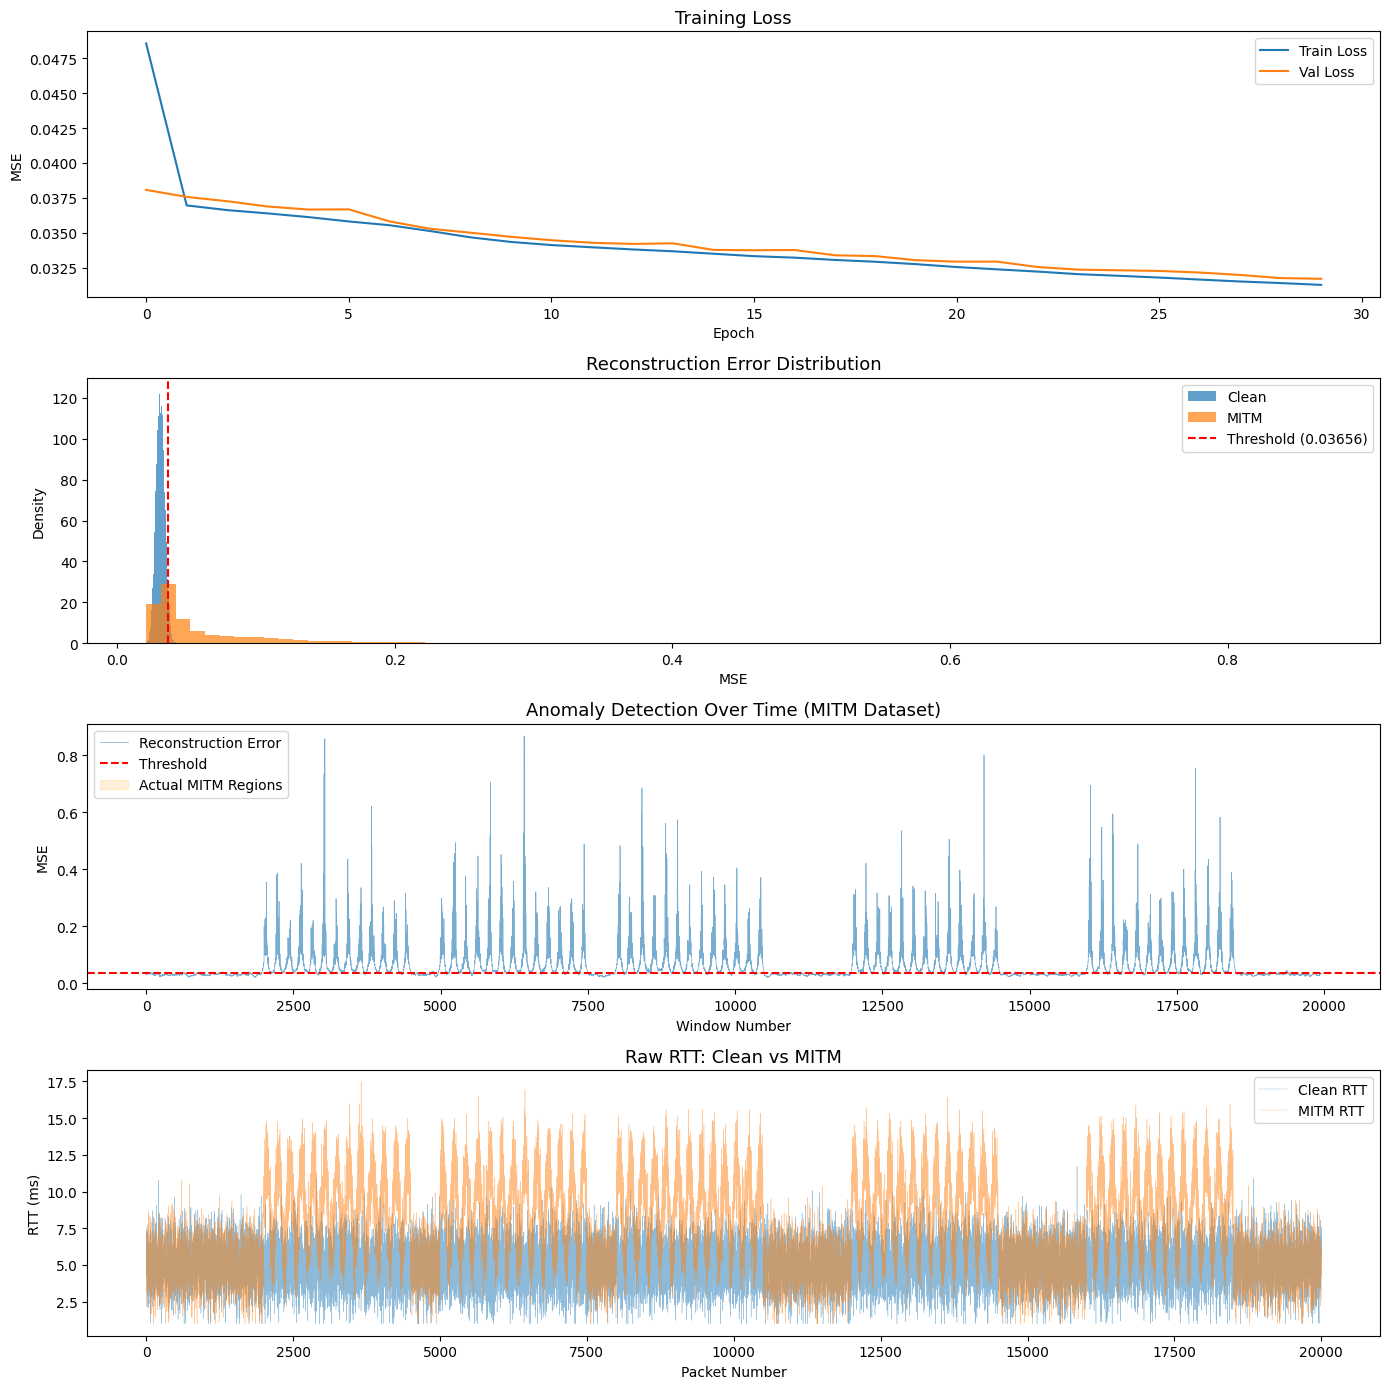


Done! Check lstm_ae_results.png


In [10]:
# ============================================================
# 8. VISUALIZE
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Plot 1: Training loss
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Training Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

# Plot 2: Error distribution
axes[1].hist(clean_errors, bins=80, alpha=0.7, label="Clean", density=True)
axes[1].hist(mitm_errors, bins=80, alpha=0.7, label="MITM", density=True)
axes[1].axvline(threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.5f})")
axes[1].set_title("Reconstruction Error Distribution", fontsize=13)
axes[1].set_xlabel("MSE")
axes[1].set_ylabel("Density")
axes[1].legend()

# Plot 3: Error over time with ground truth
axes[2].plot(mitm_errors, alpha=0.6, linewidth=0.5, label="Reconstruction Error")
axes[2].axhline(threshold, color="red", linestyle="--", label="Threshold")
axes[2].fill_between(
    range(len(window_labels)),
    0, axes[2].get_ylim()[0],
    where=(window_labels == 1),
    color="orange", alpha=0.15, label="Actual MITM Regions",
    transform=axes[2].get_xaxis_transform(),
)
axes[2].set_title("Anomaly Detection Over Time (MITM Dataset)", fontsize=13)
axes[2].set_xlabel("Window Number")
axes[2].set_ylabel("MSE")
axes[2].legend()

# Plot 4: Raw RTT comparison
axes[3].plot(clean_data[:, 0], alpha=0.5, linewidth=0.3, label="Clean RTT")
axes[3].plot(mitm_data[:, 0], alpha=0.5, linewidth=0.3, label="MITM RTT")
axes[3].set_title("Raw RTT: Clean vs MITM", fontsize=13)
axes[3].set_xlabel("Packet Number")
axes[3].set_ylabel("RTT (ms)")
axes[3].legend()

plt.tight_layout()
plt.savefig("lstm_ae_results.png", dpi=150)
plt.show()

print("\nDone! Check lstm_ae_results.png")